In [1]:
import scarf
import scarf.plotting as splt

scarf.set_verbosity("WARNING")
scarf.__version__

'1.0.0'

In [2]:
scarf.fetch_dataset(
    dataset_name="kang_15K_pbmc_rnaseq", save_path="scarf_datasets", as_zarr=True
)

scarf.fetch_dataset(
    dataset_name="kang_14K_ifnb-pbmc_rnaseq", save_path="scarf_datasets", as_zarr=True
)

In [3]:
ds_ctrl = scarf.DataStore("scarf_datasets/kang_15K_pbmc_rnaseq/data.zarr/", nthreads=4)

ds_ctrl

DataStore has 8487 (14619) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'cluster_labels', 
            'RNA_percentRibo', 'RNA_nFeatures', 'RNA_leiden_cluster', 'RNA_UMAP2', 'RNA_nCounts', 
            'RNA_UMAP1'
   RNA assay has 11352 (35635) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'I__hvgs', 
            'dropOuts'

In [4]:
ds_stim = scarf.DataStore(
    "scarf_datasets/kang_14K_ifnb-pbmc_rnaseq/data.zarr", nthreads=4
)

ds_stim

DataStore has 10111 (14446) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'cluster_labels', 
            'RNA_percentRibo', 'RNA_nFeatures', 'RNA_nCounts', 'RNA_leiden_cluster', 'RNA_UMAP2', 
            'RNA_UMAP1'
   RNA assay has 11051 (35635) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'I__hvgs', 
            'dropOuts'

In [5]:
scarf.AssayMerge(
    zarr_path="scarf_datasets/kang_merged_pbmc_rnaseq.zarr",
    assays=[ds_ctrl.RNA, ds_stim.RNA],
    names=["ctrl", "stim"],
    merge_assay_name="RNA",
    overwrite=True,
).dump()

In [6]:
ds = scarf.DataStore("scarf_datasets/kang_merged_pbmc_rnaseq.zarr", nthreads=4)

Minimum cell count (562) is lower than size factor multiplier (1000)



In [7]:
ds

DataStore has 29065 (29065) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentMito', 'orig_RNA_UMAP1', 
            'orig_RNA_percentMito', 'orig_RNA_nCounts', 'orig_RNA_percentRibo', 'orig_RNA_UMAP2', 'orig_cluster_labels', 
            'RNA_nFeatures', 'orig_RNA_leiden_cluster', 'RNA_percentRibo', 'orig_RNA_nFeatures', 'RNA_nCounts', 
          
   RNA assay has 12450 (35635) features and following metadata:
            'I', 'ids', 'names', 'nCells', 'dropOuts', 
          

In [8]:
ds.cells.head()

,I,ids,names,RNA_percentMito,orig_RNA_UMAP1,orig_RNA_percentMito,orig_RNA_nCounts,orig_RNA_percentRibo,orig_RNA_UMAP2,orig_cluster_labels,RNA_nFeatures,RNA_percentRibo,orig_RNA_leiden_cluster,orig_RNA_nFeatures,RNA_nCounts
0,True,ctrl__TGTTAAGACACTGA-1,TGTTAAGACACTGA-1,0.000000,NaN,0.000000,574.0,20.034843,NaN,nan,304.0,20.034843,-1,304.0,574.0
1,True,ctrl__TCACCCGAGCTATG-1,TCACCCGAGCTATG-1,0.000000,NaN,0.000000,1682.0,0.059453,NaN,nan,62.0,0.059453,-1,62.0,1682.0
2,True,ctrl__TCACCCGAACCACA-1,TCACCCGAACCACA-1,0.171233,-1.768571,0.171233,1168.0,31.763699,-5.990341,CD4 Memory T,434.0,31.763699,1,434.0,1168.0
3,True,ctrl__TGTAGTCTACCAGT-1,TGTAGTCTACCAGT-1,0.185357,-3.052445,0.185357,2158.0,32.483781,-12.830768,CD8 T,837.0,32.483781,7,837.0,2158.0
4,True,ctrl__TATCAGCTAGTAGA-1,TATCAGCTAGTAGA-1,0.143369,-12.654625,0.143369,1395.0,34.695341,-5.425503,B,592.0,34.695341,5,592.0,1395.0


In [9]:
ds.cells.insert(
    column_name="sample_id",
    values=[x.split("__")[0] for x in ds.cells.fetch_all("ids")],
    overwrite=True,
)

In [10]:
ctrl_labels = list(ds_ctrl.cells.fetch_all("cluster_labels"))
stim_labels = list(ds_stim.cells.fetch_all("cluster_labels"))

ds.cells.insert(
    column_name="imported_labels", values=ctrl_labels + stim_labels, overwrite=True
)

In [11]:
ctrl_valid_cells = list(ds_ctrl.cells.fetch_all("I"))
stim_valid_cells = list(ds_stim.cells.fetch_all("I"))

ds.cells.update_key(values=ctrl_valid_cells + stim_valid_cells, key="I")

In [12]:
ds.cells.to_pandas_dataframe(["sample_id"], key="I")["sample_id"].value_counts()

sample_id
ctrl    9441
stim    9157
Name: count, dtype: int64

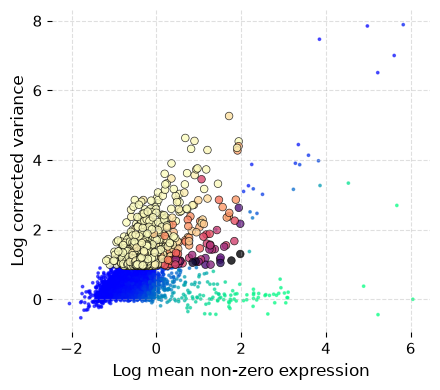

In [13]:
ds.mark_hvgs(min_cells=10, top_n=2000, min_mean=-3, max_mean=2, max_var=6)

In [14]:
ds.make_graph(feat_key="hvgs", k=21, dims=25, n_centroids=100)

In [15]:
ds.run_umap(n_epochs=250, spread=5, min_dist=1, parallel=True)

/home/parashar/scarf/scarf/metadata.py:416: RuntimeWarning: overflow encountered in cast
  a = np.empty(self.N).astype(values.dtype)


In [16]:
ds.cells.head()

,I,ids,names,RNA_percentMito,orig_RNA_UMAP1,orig_RNA_percentMito,orig_RNA_nCounts,orig_RNA_percentRibo,orig_cluster_labels,orig_RNA_UMAP2,RNA_percentRibo,orig_RNA_nFeatures,RNA_nFeatures,orig_RNA_leiden_cluster,RNA_nCounts,RNA_UMAP2,imported_labels,RNA_UMAP1,sample_id
0,True,ctrl__TGTTAAGACACTGA-1,TGTTAAGACACTGA-1,0.000000,NaN,0.000000,574.0,20.034843,nan,NaN,20.034843,304.0,304.0,-1,574.0,-14.692642,CD4 naive T,-15.208761,ctrl
1,True,ctrl__TCACCCGAGCTATG-1,TCACCCGAGCTATG-1,0.000000,NaN,0.000000,1682.0,0.059453,nan,NaN,0.059453,62.0,62.0,-1,1682.0,-9.565103,CD 14 Mono,33.979362,ctrl
2,True,ctrl__TCACCCGAACCACA-1,TCACCCGAACCACA-1,0.171233,-1.768571,0.171233,1168.0,31.763699,CD4 Memory T,-5.990341,31.763699,434.0,434.0,1,1168.0,-27.453821,CD 14 Mono,2.517110,ctrl
3,True,ctrl__TGTAGTCTACCAGT-1,TGTAGTCTACCAGT-1,0.185357,-3.052445,0.185357,2158.0,32.483781,CD8 T,-12.830768,32.483781,837.0,837.0,7,2158.0,-22.171509,CD 14 Mono,-7.781567,ctrl
4,False,ctrl__TATCAGCTAGTAGA-1,TATCAGCTAGTAGA-1,0.143369,-12.654625,0.143369,1395.0,34.695341,B,-5.425503,34.695341,592.0,592.0,5,1395.0,NaN,nan,NaN,ctrl


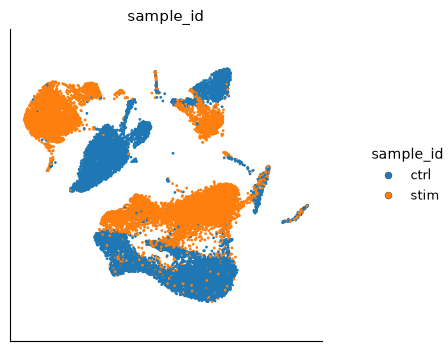

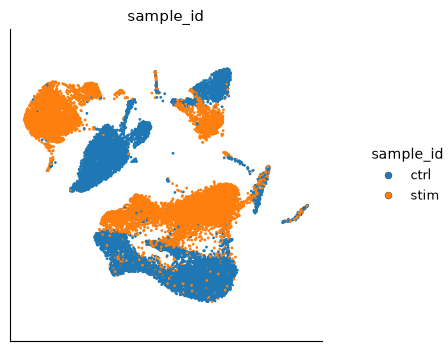

In [17]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="sample_id",
    legend_loc="right",
).figure

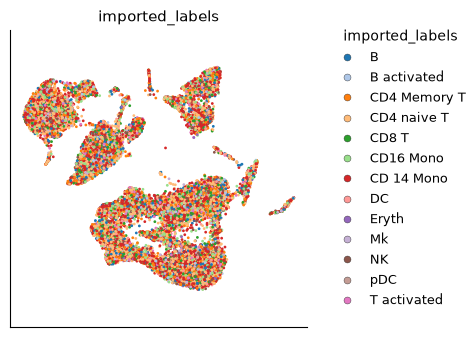

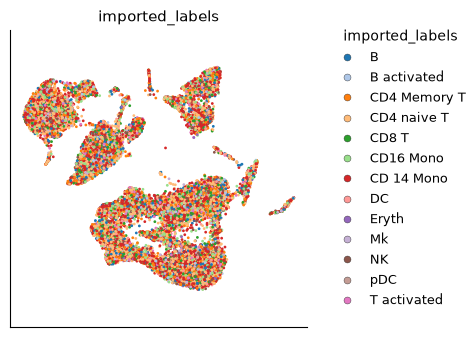

In [18]:
splt.embedding(
    ds,
    layout_key="RNA_UMAP",
    color_by="imported_labels",
    legend_loc="right",
).figure

In [19]:
ds.cells.insert(
    column_name="is_ctrl",
    values=(ds.cells.fetch_all("sample_id") == "ctrl"),
    overwrite=True,
)

In [20]:
ds.make_graph(feat_key="hvgs", k=21, dims=25, n_centroids=100, pca_cell_key="is_ctrl")

In [21]:
ds.run_umap(n_epochs=250, spread=5, min_dist=1, parallel=True, label="pUMAP")

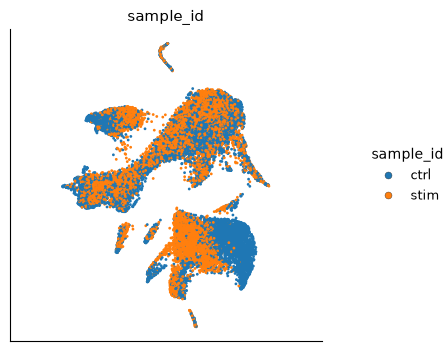

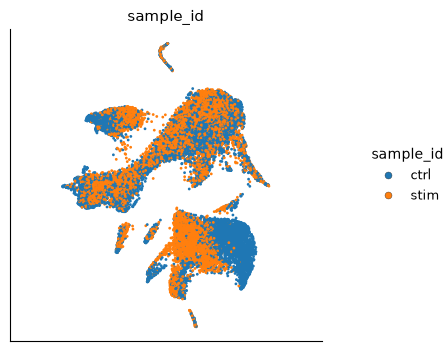

In [22]:
splt.embedding(
    ds,
    layout_key="RNA_pUMAP",
    color_by="sample_id",
    legend_loc="right",
).figure

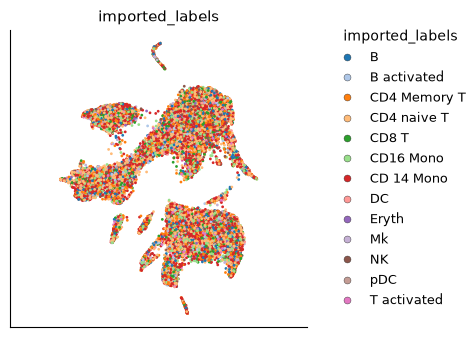

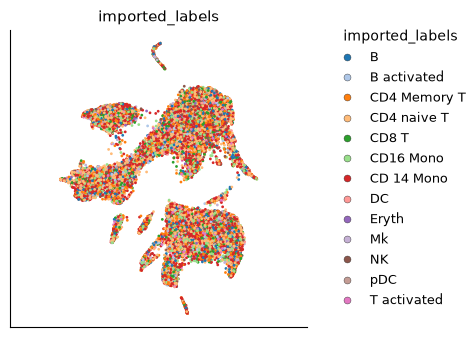

In [23]:
splt.embedding(
    ds,
    layout_key="RNA_pUMAP",
    color_by="imported_labels",
    legend_loc="right",
).figure

In [24]:
ds.make_graph(
    feat_key="hvgs",
    k=21,
    dims=25,
    n_centroids=100,
    harmonize=True,
    batch_columns=["sample_id"],
)

ds.run_umap(n_epochs=250, spread=5, min_dist=1, parallel=True, label="hUMAP")

ds.run_leiden_clustering(resolution=1.0)

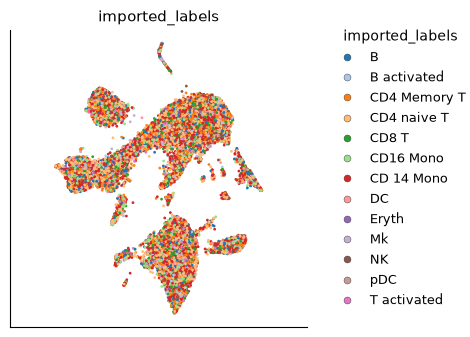

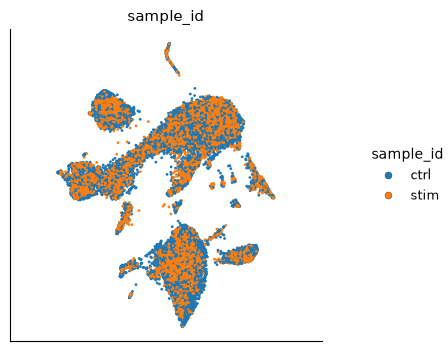

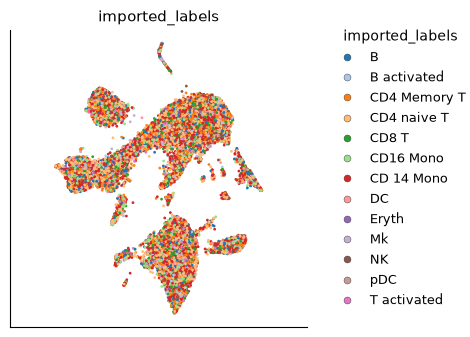

In [25]:
splt.embedding(
    ds,
    layout_key="RNA_hUMAP",
    color_by="sample_id",
    legend_loc="right",
).figure

splt.embedding(
    ds,
    layout_key="RNA_hUMAP",
    color_by="imported_labels",
    legend_loc="right",
).figure

In [26]:
ds.metric_lisi(
    label_colnames=["sample_id", "imported_labels"],
    save_result=True,
)

Perplexity 30 requires at least 90 neighbors, but the graph has 21. Using perplexity 7.



[('sample_id',
  array([1.82219041, 1.47875387, 1.72050892, ..., 1.9986971 , 1.29487023,
         1.04752205], shape=(18598,))),
 ('imported_labels',
  array([2.72212043, 3.65864004, 2.12411135, ..., 3.33422435, 2.20356394,
         4.4492713 ], shape=(18598,)))]

In [27]:
ds.metric_batch_mixing(label_colname="sample_id")

Perplexity 30 requires at least 90 neighbors, but the graph has 21. Using perplexity 7.



0.4225426493670202

In [28]:
ds.metric_silhouette(res_label="leiden_cluster")

array([ 0.25132455,  0.23440473,  0.11844284,  0.4121762 ,  0.22050369,
        0.06412872,  0.21549733,  0.29761931,  0.08568681,  0.05195516,
        0.10802172,  0.48158152,  0.50115504,  0.32112733,  0.31548232,
       -0.06508764,  0.09314139,  0.16435866])

In [29]:
ds.metric_label_concordance(
    label_columns=["RNA_leiden_cluster", "imported_labels"], metric="ari"
)

0.6711265318454732